In [1]:
from sqlalchemy import create_engine , text
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os
from scipy.stats import pearsonr
from warnings import filterwarnings
filterwarnings("ignore")

In [2]:
engine = create_engine(
    f"mysql+mysqlconnector://{os.environ['DB_USER']}:{os.environ['DB_PASSWORD']}@{os.environ['DB_HOST']}/{os.environ['DB_NAME']}"
)

with engine.connect() as conn:
    result = conn.execute(text("SHOW TABLES"))
    tables = [row[0] for row in result]

print("Total Tables:", len(tables))
print("Table Names:")
for table in tables:
    print("-", table)

Total Tables: 2
Table Names:
- clean_dataset
- student_social_media_and_mental_health


In [3]:
for table in tables:
       query = text(f"SELECT COUNT(*) FROM {table}")
       df = pd.read_sql_query(query, engine)
       print(f"{table}", df.iloc[0,0])
       df = pd.read_sql(f"SELECT * FROM {table}", engine)
       display(df.head(5))

clean_dataset 4998


,Age,Gender,Country,Academic_Level,Most_Used_Platform,Purpose_Of_Use,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Stress_Level,Mental_Health_Score
0,21,Male,Other,Undergraduate,Facebook,Networking,4.0,134.0,4.5,2.2,6.7,Medium,6.8
1,23,Female,Other,Graduate,LinkedIn,Education,1.6,73.0,7.0,2.4,8.6,Low,7.6
2,22,Male,Canada,Undergraduate,Instagram,Entertainment,4.6,166.0,4.0,1.8,6.7,Medium,7.0
3,18,Male,Other,High School,Snapchat,Entertainment,7.0,220.0,1.0,1.7,5.4,Very High,5.3
4,24,Female,Other,Graduate,Facebook,Networking,7.5,237.0,1.0,1.1,5.0,Very High,4.4


student_social_media_and_mental_health 5000


,Age,Gender,Country,Academic_Level,Most_Used_Platform,Purpose_Of_Use,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Stress_Level,Mental_Health_Score
0,21,Male,Other,Undergraduate,Facebook,Networking,4.0,134.0,4.5,2.2,6.7,Medium,6.8
1,23,Female,Other,Graduate,LinkedIn,Education,1.6,73.0,7.0,2.4,8.6,Low,7.6
2,22,Male,Canada,Undergraduate,Instagram,Entertainment,4.6,166.0,4.0,1.8,6.7,Medium,7.0
3,18,Male,Other,High School,Snapchat,Entertainment,7.0,220.0,1.0,1.7,5.4,Very High,5.3
4,24,Female,Other,Graduate,Facebook,Networking,7.5,237.0,1.0,1.1,5.0,Very High,4.4


In [4]:
data = pd.read_sql_query(text("""select * from clean_dataset """),engine)

In [5]:
data.describe()

,Age,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Mental_Health_Score
count,4998.000000,4998.000000,4998.000000,4998.000000,4998.000000,4998.000000,4998.000000
mean,20.822129,5.078491,171.455582,3.008403,1.750760,6.634654,6.231152
std,1.736774,1.654097,42.859829,1.636831,0.668406,1.221561,1.278476
min,18.000000,1.000000,62.000000,0.300000,-0.400000,3.600000,3.600000
25%,19.000000,3.800000,140.000000,1.500000,1.300000,5.600000,5.100000
50%,21.000000,5.000000,171.000000,2.800000,1.700000,6.600000,6.100000
75%,22.000000,6.300000,204.000000,4.200000,2.200000,7.500000,7.100000
max,24.000000,8.800000,273.000000,8.300000,4.100000,9.900000,9.400000


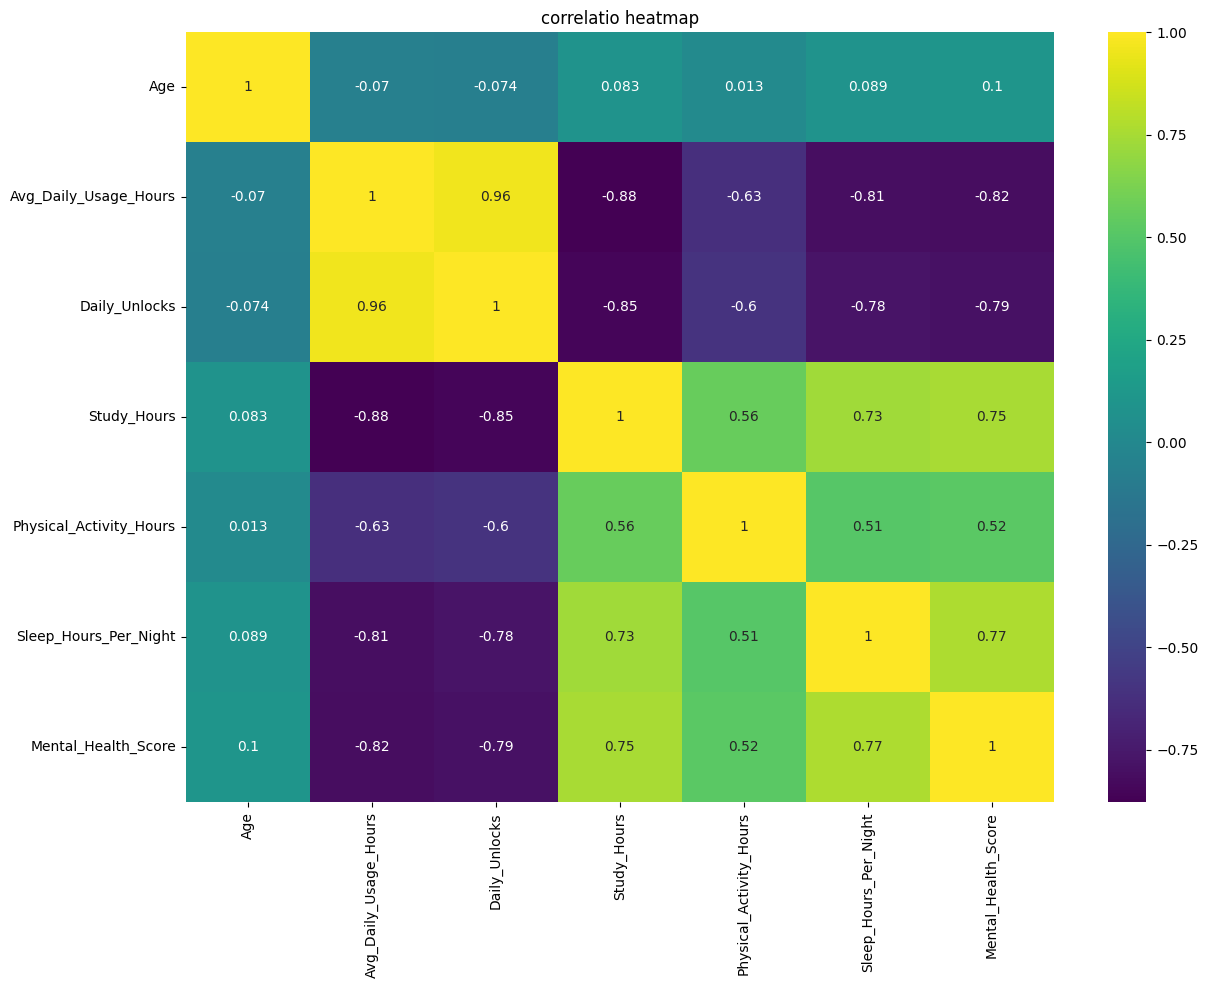

In [9]:
numeric_cols = data.select_dtypes(include=['int64','float64'])
plt.figure(figsize=(14,10))
sns.heatmap(numeric_cols.corr() , annot=True ,cmap="viridis" )
plt.title("correlatio heatmap")
plt.show()

***strong Positive Correlations***

Avg_Daily_Usage_Hours ↔ Daily_Unlocks (0.96)
Almost perfect positive correlation: As average daily phone usage increases, the number of daily unlocks also increases significantly.


Study_Hours ↔ Mental_Health_Score (0.75)
Strong positive correlation: More study hours are associated with higher mental health scores.


Sleep_Hours_Per_Night ↔ Mental_Health_Score (0.77)
Strong positive correlation: More sleep per night is linked to better mental health scores.


Study_Hours ↔ Sleep_Hours_Per_Night (0.73)
Strong positive correlation: More study hours are associated with more sleep hours

***Strong Negative Correlations***


Avg_Daily_Usage_Hours ↔ Study_Hours (-0.88)
Strong negative correlation: Higher phone usage is associated with fewer study hours.


Avg_Daily_Usage_Hours ↔ Sleep_Hours_Per_Night (-0.81)
Strong negative correlation: More phone usage is linked to less sleep.


Avg_Daily_Usage_Hours ↔ Mental_Health_Score (-0.82)
Strong negative correlation: Higher phone usage is associated with lower mental health scores.


Daily_Unlocks ↔ Study_Hours (-0.85)
Strong negative correlation: More daily unlocks are linked to fewer study hours.


Daily_Unlocks ↔ Sleep_Hours_Per_Night (-0.78)
Strong negative correlation: More daily unlocks are associated with less sleep.


Daily_Unlocks ↔ Mental_Health_Score (-0.79)
Strong negative correlation: More daily unlocks are linked to lower mental health scores

***Moderate Correlations***


Physical_Activity_Hours ↔ Study_Hours (0.56)
Moderate positive correlation: More physical activity is somewhat associated with more study hours.


Physical_Activity_Hours ↔ Sleep_Hours_Per_Night (0.51)
Moderate positive correlation: More physical activity is somewhat linked to more sleep.


Physical_Activity_Hours ↔ Mental_Health_Score (0.52)
Moderate positive correlation: More physical activity is somewhat associated with better mental health.



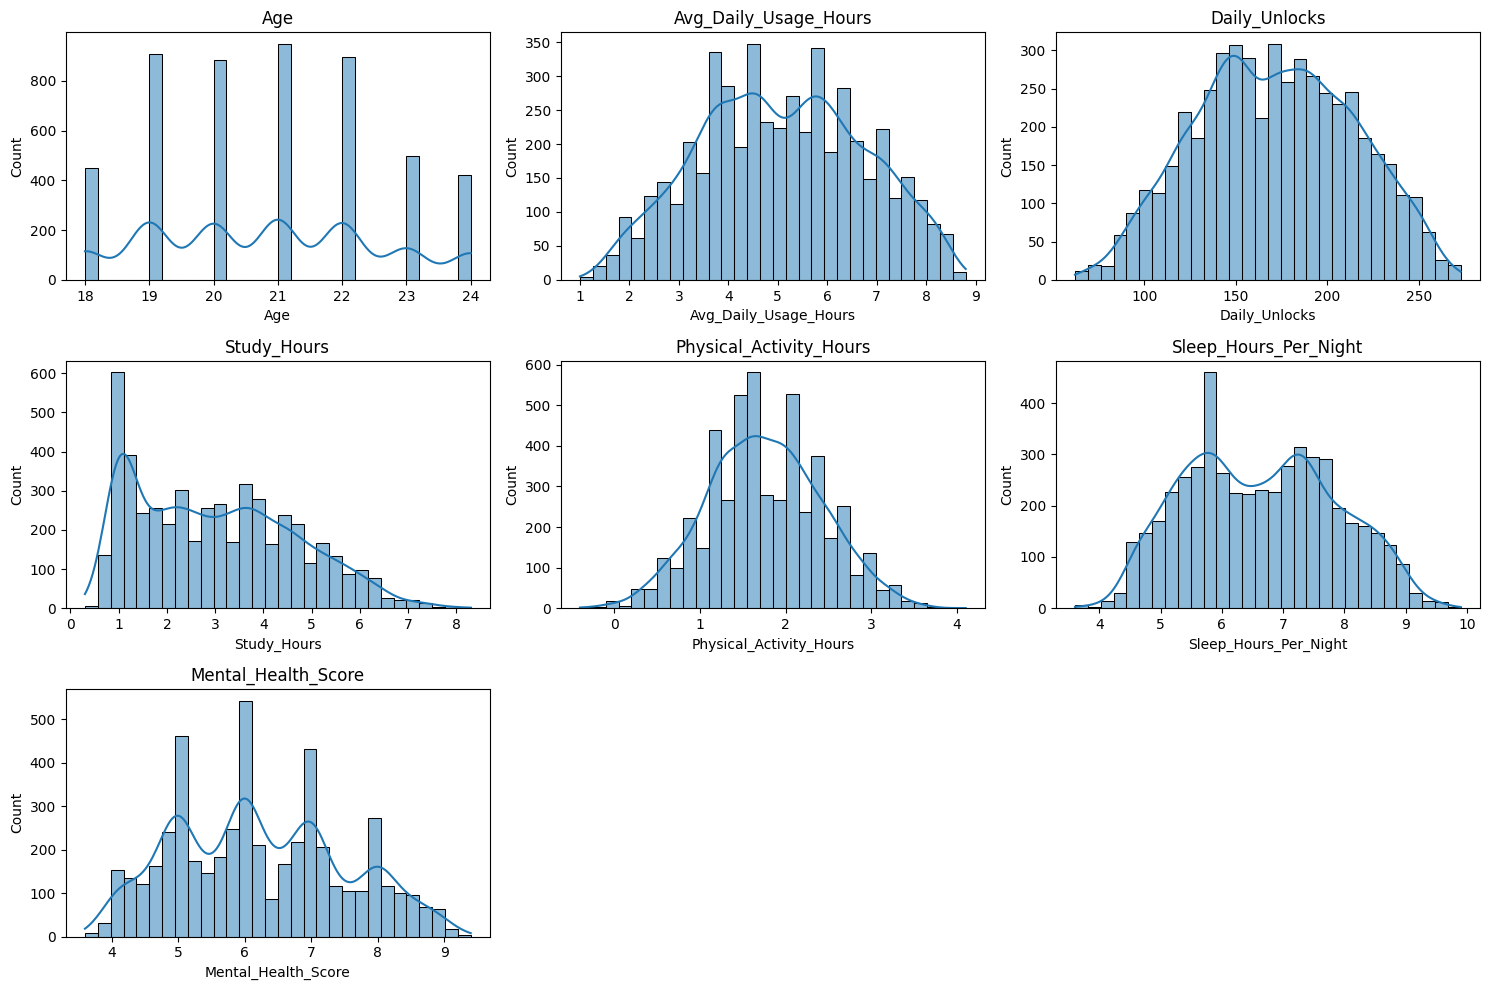

In [12]:
# distribution plot for numerical columns
numerical_cols = df.select_dtypes(include=["float64", "int64"]).columns
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(3, 3, i + 1) # adjust the number of rows and columns as needed
    sns.histplot(df[col], kde=True , bins = 30)
    plt.title(col)
plt.tight_layout()
plt.show()

# Phase 1: who are this students ?

1 . What is the distribution of students by Academic_Level (High School / Undergraduate / Graduate) and Gender?

,Academic_Level,gender,total_students,pct_of_total
0,Undergraduate,Male,1871,37.43
1,Undergraduate,Female,1759,35.19
2,Graduate,Male,489,9.78
3,Graduate,Female,429,8.58
4,High School,Male,274,5.48
5,High School,Female,176,3.52


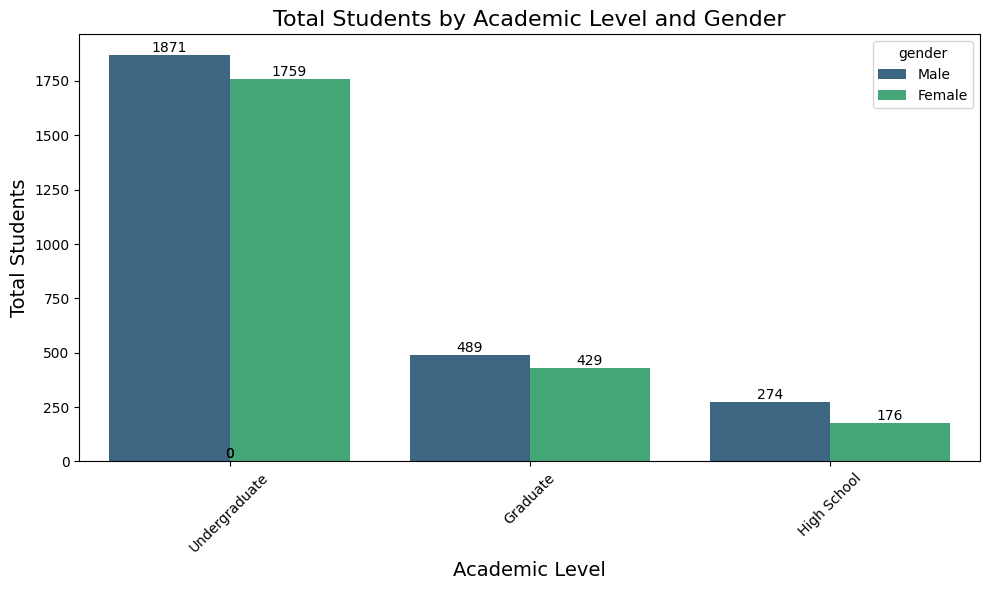

In [30]:
academic_students = pd.read_sql_query(text("""select Academic_Level,gender , count(*) as total_students , 
round(count(*) * 100.0 / sum(count(*)) over(),2) as pct_of_total from clean_dataset 
group by Academic_Level , gender order by total_students desc """),engine)
display(academic_students)

plt.figure(figsize=(10, 6))
ax = sns.barplot(
    data=academic_students,
    x="Academic_Level",
    y="total_students",
    hue="gender",
    palette="viridis"
)

# Add title and labels
plt.title("Total Students by Academic Level and Gender", fontsize=16)
plt.xlabel("Academic Level", fontsize=14)
plt.ylabel("Total Students", fontsize=14)

# Rotate x-axis labels for better readability
plt.xticks(rotation=45)
for p in ax.patches:
    ax.annotate(
        f"{int(p.get_height())}",
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center',
        va='center',
        xytext=(0, 5),
        textcoords='offset points'
    )

# Show the plot
plt.tight_layout()
plt.show()

2. Which Most_Used_Platform dominates overall — and does the ranking shift across Academic Levels?

In [42]:
platform = pd.read_sql_query(text("""
WITH platform_counts AS (
    SELECT 
        Academic_Level,
        Most_Used_Platform,
        COUNT(*) AS total_students
    FROM clean_dataset 
    GROUP BY Academic_Level, Most_Used_Platform
),
ranked AS (
    SELECT 
        Academic_Level,
        Most_Used_Platform,
        total_students,
        ROW_NUMBER() OVER (PARTITION BY Academic_Level ORDER BY total_students DESC) AS rank_in_level
    FROM platform_counts
)
SELECT 
    Academic_Level,
    Most_Used_Platform,
    total_students,
    rank_in_level
FROM ranked
ORDER BY total_students desc;"""),engine)
display(platform)

,Academic_Level,Most_Used_Platform,total_students,rank_in_level
0,Undergraduate,Instagram,915,1
1,Undergraduate,TikTok,721,2
2,Undergraduate,Facebook,548,3
3,Undergraduate,YouTube,325,4
4,Undergraduate,LinkedIn,294,5
5,Undergraduate,Twitter,267,6
6,Undergraduate,Snapchat,228,7
7,Undergraduate,WhatsApp,175,8
8,Graduate,Instagram,165,1
9,Graduate,TikTok,148,2


3. What is the distribution of Purpose_Of_Use (Entertainment, Education, Networking, News)?

,Purpose_Of_Use,total_students,pct_of_total
0,Entertainment,2551,51.04
1,Education,1093,21.87
2,Networking,793,15.87
3,News,561,11.22


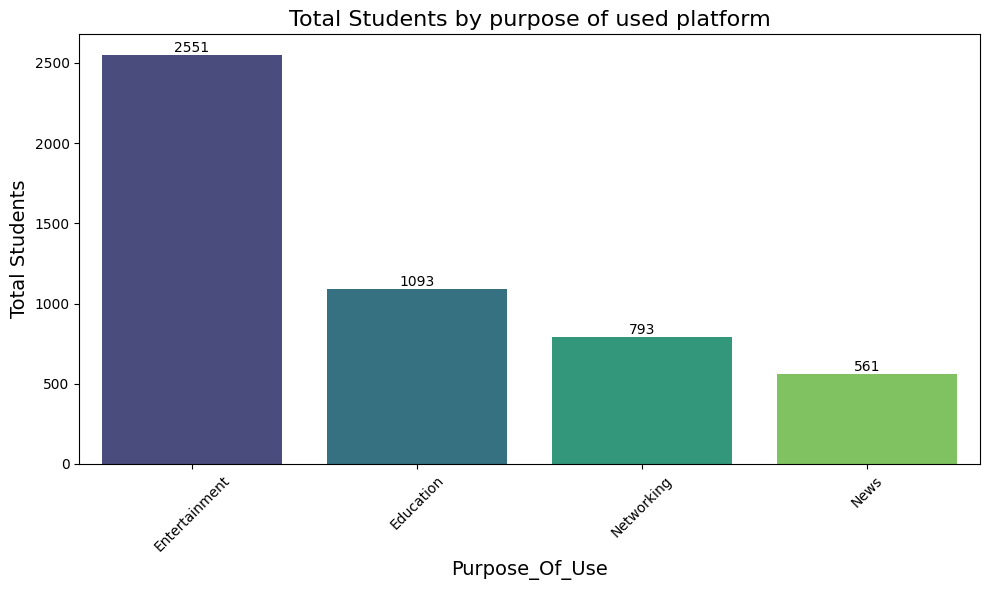

In [47]:
purpose_of_use = pd.read_sql_query(text("""select Purpose_Of_Use , count(*) as total_students , round(count(*) * 100.0 / sum(count(*)) over(),2) as pct_of_total from clean_dataset group by Purpose_Of_Use order by total_students desc """),engine)
display(purpose_of_use)
plt.figure(figsize=(10, 6))
ax = sns.barplot(
    data=purpose_of_use,
    x="Purpose_Of_Use",
    y="total_students",
    hue="Purpose_Of_Use",
    palette="viridis"
)

# Add title and labels
plt.title("Total Students by purpose of used platform", fontsize=16)
plt.xlabel("Purpose_Of_Use", fontsize=14)
plt.ylabel("Total Students", fontsize=14)

# Rotate x-axis labels for better readability
plt.xticks(rotation=45)
for p in ax.patches:
    ax.annotate(
        f"{int(p.get_height())}",
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center',
        va='center',
        xytext=(0, 5),
        textcoords='offset points'
    )

# Show the plot
plt.tight_layout()
plt.show()


4. What are the average values of Avg_Daily_Usage_Hours, Sleep_Hours_Per_Night, Study_Hours, and Physical_Activity_Hours across the full dataset?

In [48]:
pd.read_sql_query(text("""select round(avg(Avg_Daily_Usage_Hours),2) as avg_daily_usage_hour , round(avg(Sleep_Hours_Per_Night),2) as sleep_hour ,round(avg(Study_Hours) ,2) as avg_study_hour , round(avg(Physical_Activity_Hours),2) as avg_physical_activity_hour from clean_dataset """),engine)

,avg_daily_usage_hour,sleep_hour,avg_study_hour,avg_physical_activity_hour
0,5.08,6.63,3.01,1.75


5. What does the distribution of Mental_Health_Score look like? Is it normally distributed, left-skewed, or right-skewed?

0.2065673061644126


Text(0, 0.5, 'Frequency')

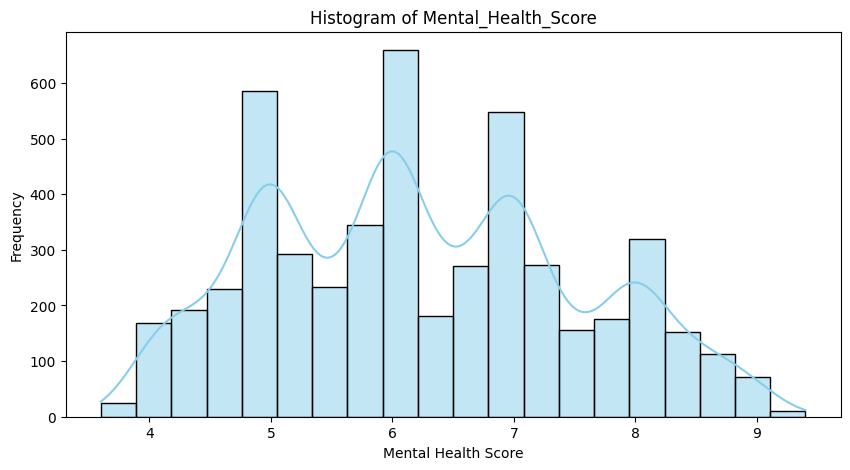

In [ ]:
print(df['Mental_Health_Score'].skew())
plt.figure(figsize=(10,5))
sns.histplot(df['Mental_Health_Score'], kde=True, color='skyblue', bins=20)
plt.title('Histogram of Mental_Health_Score')
plt.xlabel('Mental Health Score')
plt.ylabel('Frequency')

* The distribution of Mental_Health_Score appears approximately normal with a slight positive (right) skew. The skewness value is 0.206, which is close to zero and falls within the range of -0.5 to +0.5, indicating that the data is fairly symmetric.

* The histogram also shows most scores clustered around the center (5–7) with a slightly longer tail toward higher scores, suggesting mild right skewness but no severe departure from normality.

6. What is the breakdown of students across Stress_Level categories (Low / Medium / High / Very High)?

,Stress_Level,total_students,pct_of_total
0,Very High,1621,32.43
1,High,1439,28.79
2,Medium,1295,25.91
3,Low,643,12.87


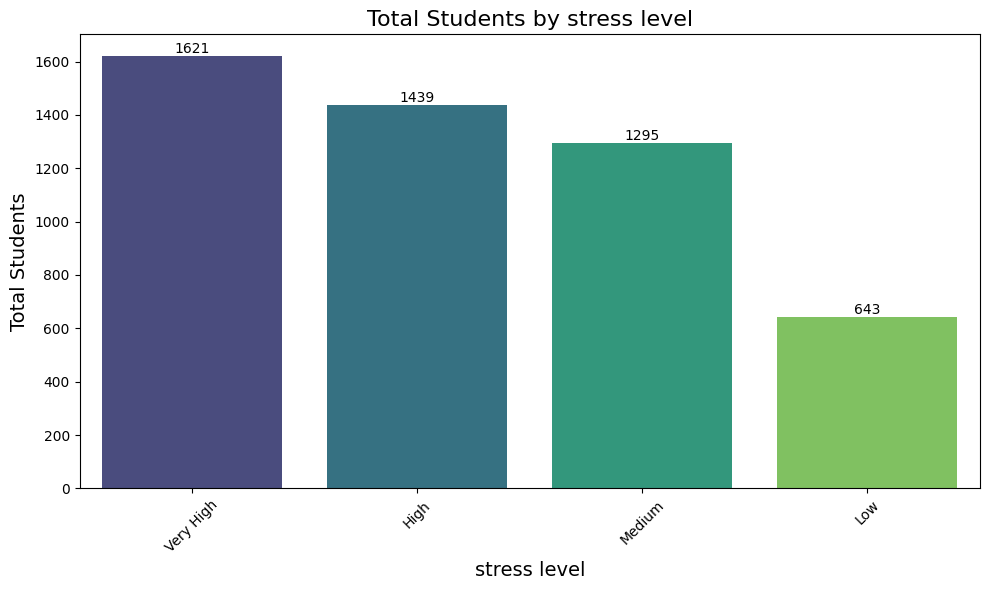

In [7]:
stress_level = pd.read_sql_query(text("""select  Stress_Level  , count(*) as total_students , round(count(*) * 100.0 / sum(count(*)) over(),2) as pct_of_total from clean_dataset group by Stress_Level  order by total_students desc """),engine)
display(stress_level)

plt.figure(figsize=(10, 6))
ax = sns.barplot(
    data=stress_level,
    x="Stress_Level",
    y="total_students",
    # hue="gender",
    palette="viridis"
)

# Add title and labels
plt.title("Total Students by stress level", fontsize=16)
plt.xlabel("stress level", fontsize=14)
plt.ylabel("Total Students", fontsize=14)

# Rotate x-axis labels for better readability
plt.xticks(rotation=45)
for p in ax.patches:
    ax.annotate(
        f"{int(p.get_height())}",
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center',
        va='center',
        xytext=(0, 5),
        textcoords='offset points'
    )

# Show the plot
plt.tight_layout()
plt.show()


# Phase 2 : Diagnostic(what's driving what)

7. Does higher Avg_Daily_Usage_Hours correlate with lower Sleep_Hours_Per_Night and lower Study_Hours?

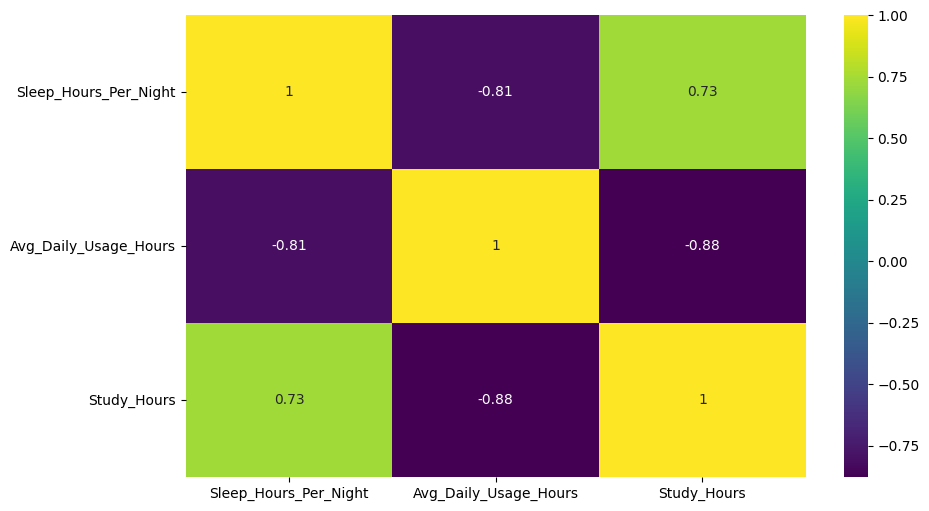

usage vs sleep distribution


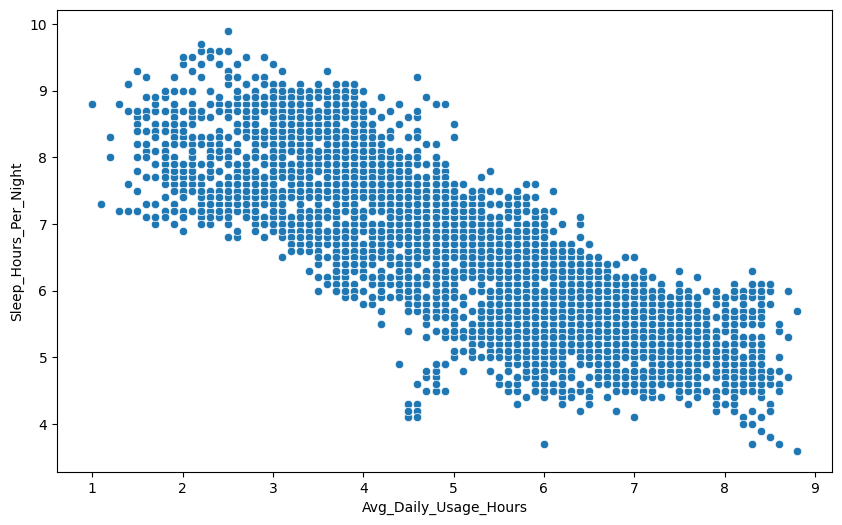

usage vs study hour distribution


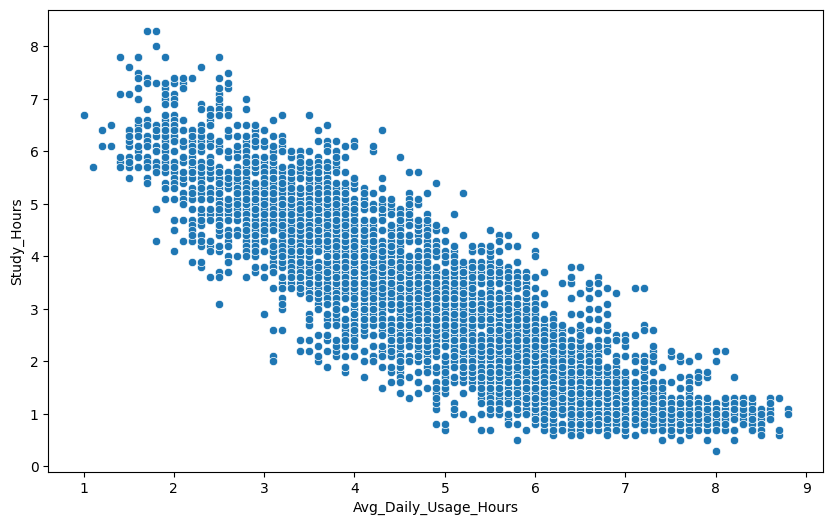


Pearson Correlations with Usage Hours:
Sleep_Hours_Per_Night: r = -0.8084, p-value = 0.00e+00
Study_Hours: r = -0.8786, p-value = 0.00e+00


In [4]:
cor = df[['Sleep_Hours_Per_Night' , 'Avg_Daily_Usage_Hours' , 'Study_Hours']]
plt.figure(figsize=(10,6))
sns.heatmap(cor.corr() , annot=True ,cmap="viridis" )
plt.show()

# usage vs sleep
print("usage vs sleep distribution")
plt.figure(figsize=(10,6))
sns.scatterplot(
    data=df,
    x='Avg_Daily_Usage_Hours',
    y='Sleep_Hours_Per_Night'   
)
plt.show()

print("usage vs study hour distribution")

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x='Avg_Daily_Usage_Hours',
    y='Study_Hours'
)
plt.show()

print("\nPearson Correlations with Usage Hours:")
for var in ['Sleep_Hours_Per_Night', 'Study_Hours']:
    corr, p_value = pearsonr(df['Avg_Daily_Usage_Hours'], df[var])
    print(f"{var}: r = {corr:.4f}, p-value = {p_value:.2e}")

8. Which platform is associated with the highest average daily usage hours, and which is associated with the lowest Mental_Health_Score?

,Most_Used_Platform,total_students,avg_usage_hour,mental_health
0,WhatsApp,175,6.43,5.58
1,TikTok,918,5.26,5.99
2,Snapchat,419,5.26,6.12
3,Twitter,462,5.16,6.35
4,YouTube,491,5.15,6.22
5,WeChat,36,4.96,6.49
6,Facebook,719,4.93,6.40
7,Instagram,1130,4.92,6.19
8,LinkedIn,522,4.83,6.49
9,KakaoTalk,36,4.81,5.98


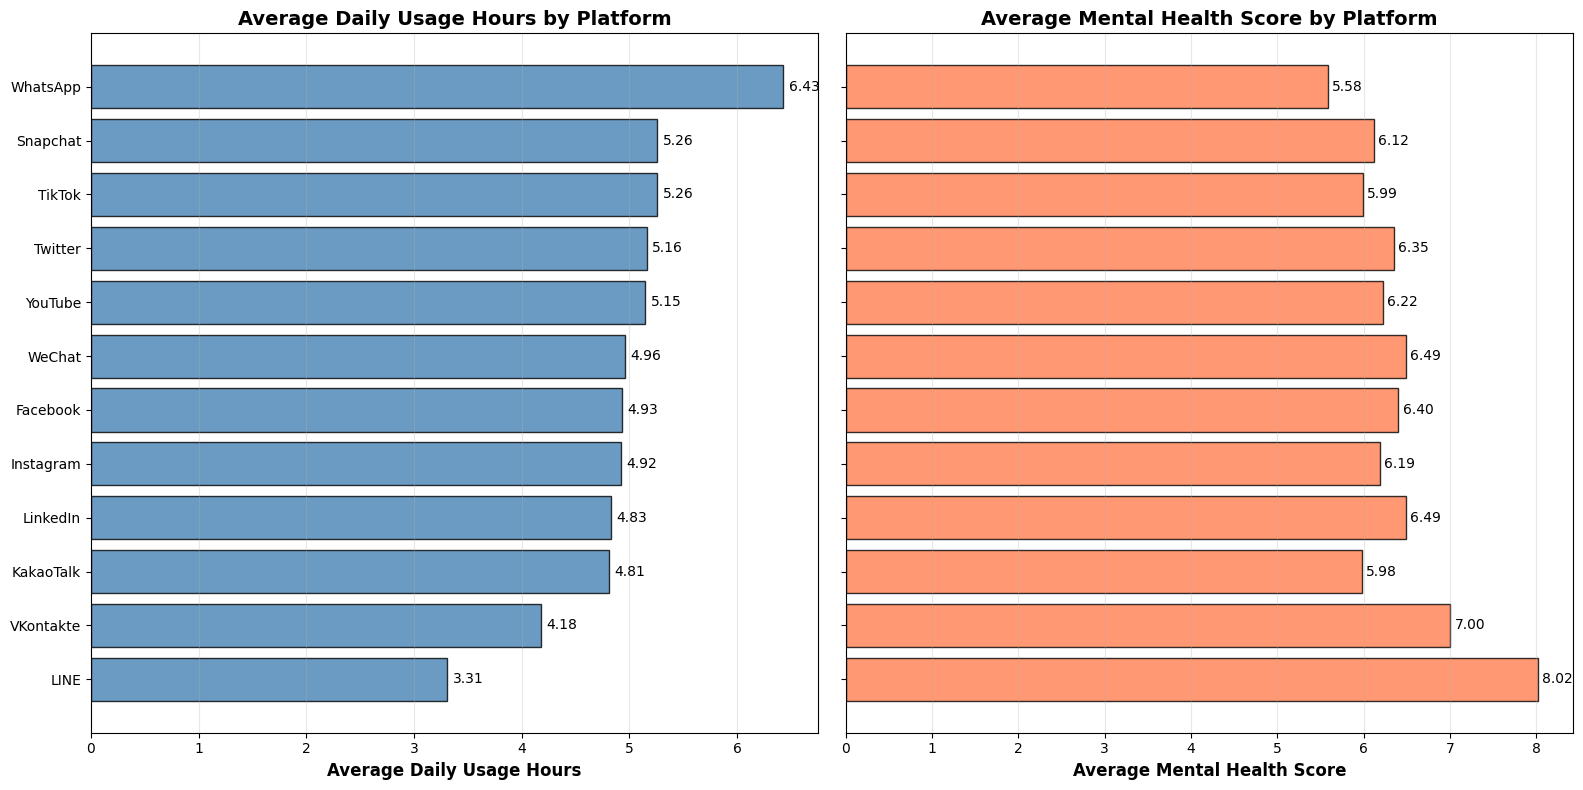

In [17]:
platform  = pd.read_sql_query(text("""select Most_Used_Platform , count(*) as total_students , round(avg(Avg_Daily_Usage_Hours),2) as avg_usage_hour , round(avg(Mental_Health_Score),2) as mental_health from clean_dataset group by Most_Used_Platform order by avg_usage_hour desc , mental_health"""),engine)
display(platform)

# Phase 2, Question 8: Side-by-side horizontal bar chart
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

# Sort by avg_usage_hour for consistency
platform_sorted = platform.sort_values('avg_usage_hour', ascending=True)

# Left chart - Average Usage Hours
ax1.barh(platform_sorted['Most_Used_Platform'], platform_sorted['avg_usage_hour'], 
         color='steelblue', alpha=0.8, edgecolor='black')
ax1.set_xlabel('Average Daily Usage Hours', fontsize=12, fontweight='bold')
ax1.set_title('Average Daily Usage Hours by Platform', fontsize=14, fontweight='bold')
ax1.grid(axis='x', alpha=0.3)

# Add value labels on bars
for i, v in enumerate(platform_sorted['avg_usage_hour']):
    ax1.text(v + 0.05, i, f'{v:.2f}', va='center', fontsize=10)

# Right chart - Mental Health Score
ax2.barh(platform_sorted['Most_Used_Platform'], platform_sorted['mental_health'], 
         color='coral', alpha=0.8, edgecolor='black')
ax2.set_xlabel('Average Mental Health Score', fontsize=12, fontweight='bold')
ax2.set_title('Average Mental Health Score by Platform', fontsize=14, fontweight='bold')
ax2.grid(axis='x', alpha=0.3)

# Add value labels on bars
for i, v in enumerate(platform_sorted['mental_health']):
    ax2.text(v + 0.05, i, f'{v:.2f}', va='center', fontsize=10)

# Remove y-axis labels from right chart to avoid duplication
ax2.set_yticklabels([])

plt.tight_layout()
plt.show()

9. Does Purpose_Of_Use impact Mental_Health_Score? Specifically, do students using social media for Education score higher than those using it for Entertainment?

,Purpose_Of_Use,total_students,avg_mental_health,maximum,minimum
0,Networking,793,6.38,9.2,3.8
1,Education,1093,6.35,9.3,3.7
2,Entertainment,2551,6.11,9.4,3.6
3,News,561,6.32,9.1,3.8


,education_avg,entertainment_avg,difference
0,6.351,6.115,0.236


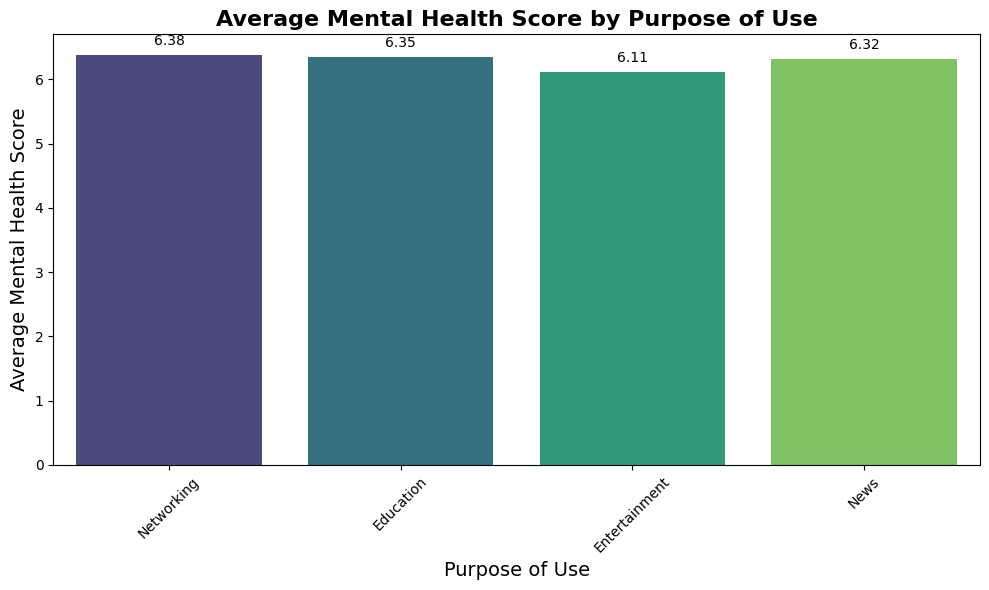

In [29]:
purpose_of_uses = pd.read_sql_query(text("""select Purpose_Of_Use , count(*) as total_students , round(avg(Mental_Health_Score),2) avg_mental_health , max(Mental_Health_Score) as maximum , min(Mental_Health_Score) as minimum from clean_dataset group by Purpose_Of_Use """),engine)
display(purpose_of_uses)

diffrence = pd.read_sql_query(text("""SELECT 
    ROUND(AVG(CASE WHEN Purpose_Of_Use = 'Education' THEN Mental_Health_Score END), 3) AS education_avg,
    ROUND(AVG(CASE WHEN Purpose_Of_Use = 'Entertainment' THEN Mental_Health_Score END), 3) AS entertainment_avg,
    ROUND(
        AVG(CASE WHEN Purpose_Of_Use = 'Education' THEN Mental_Health_Score END) - 
        AVG(CASE WHEN Purpose_Of_Use = 'Entertainment' THEN Mental_Health_Score END), 
    3) AS difference
FROM clean_dataset; """),engine)
display(diffrence)
# Phase 2, Question 9: Average Mental Health Score by Purpose of Use
plt.figure(figsize=(10, 6))
ax = sns.barplot(
    data=purpose_of_uses,
    x="Purpose_Of_Use",
    y="avg_mental_health",
    hue="Purpose_Of_Use",
    palette="viridis"
)

# Add title and labels
plt.title("Average Mental Health Score by Purpose of Use", fontsize=16, fontweight='bold')
plt.xlabel("Purpose of Use", fontsize=14)
plt.ylabel("Average Mental Health Score", fontsize=14)

# Rotate x-axis labels for better readability
plt.xticks(rotation=45)

# Add value annotations on bars
for p in ax.patches:
    ax.annotate(
        f"{p.get_height():.2f}",
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center',
        va='bottom',
        xytext=(0, 5),
        textcoords='offset points',
        fontsize=10
    )

# Remove duplicate legend
plt.legend([], frameon=False)

plt.tight_layout()
plt.show()

,education_avg,entertainment_avg,difference
0,6.351,6.115,0.236


10. Are students with Very High stress sleeping fewer hours and exercising less than Low stress students?

,Stress_Level,avg_sleep_hour,max_sleep_hour,min_sleep_hour,avg_activity,max_activity,min_activity
0,Low,8.16,9.9,6.0,2.35,3.8,0.5
1,Medium,7.57,9.5,5.7,2.05,4.1,0.2
2,High,6.45,8.5,4.1,1.73,3.6,-0.1
3,Very High,5.44,7.6,3.6,1.29,3.1,-0.4


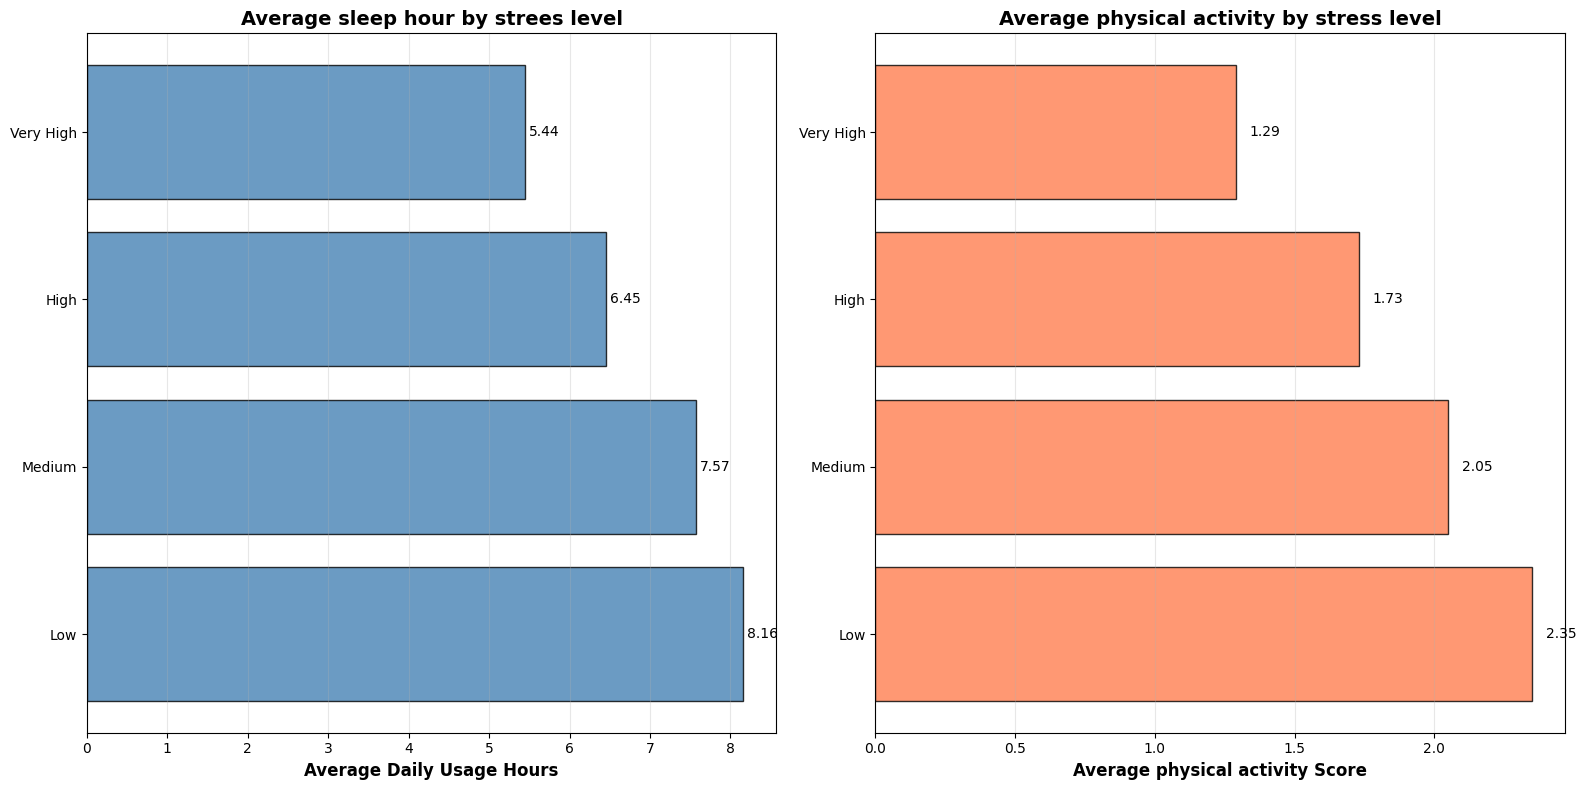

In [39]:
stress_sleep = pd.read_sql_query(text("""select Stress_Level , round(avg(Sleep_Hours_Per_Night),2) as avg_sleep_hour , max(Sleep_Hours_Per_Night) as max_sleep_hour , min(Sleep_Hours_Per_Night) as min_sleep_hour ,  round(avg(Physical_Activity_Hours),2) as avg_activity , max(Physical_Activity_Hours) as max_activity , min(Physical_Activity_Hours) as min_activity from clean_dataset group by Stress_Level order by avg_sleep_hour desc"""),engine)
display(stress_sleep)

# Phase 2, Question 8: Side-by-side horizontal bar chart
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

# Sort by avg_usage_hour for consistency
stress_sorted = stress_sleep.sort_values('avg_sleep_hour', ascending=False)

# Left chart - Average Usage Hours
ax1.barh(stress_sleep['Stress_Level'], stress_sorted['avg_sleep_hour'], 
         color='steelblue', alpha=0.8, edgecolor='black')
ax1.set_xlabel('Average Daily Usage Hours', fontsize=12, fontweight='bold')
ax1.set_title('Average sleep hour by strees level', fontsize=14, fontweight='bold')
ax1.grid(axis='x', alpha=0.3)

# Add value labels on bars
for i, v in enumerate(stress_sorted['avg_sleep_hour']):
    ax1.text(v + 0.05, i, f'{v:.2f}', va='center', fontsize=10)

# Right chart - Mental Health Score
ax2.barh(stress_sorted['Stress_Level'], stress_sorted['avg_activity'], 
         color='coral', alpha=0.8, edgecolor='black')
ax2.set_xlabel('Average physical activity Score', fontsize=12, fontweight='bold')
ax2.set_title('Average physical activity by stress level', fontsize=14, fontweight='bold')
ax2.grid(axis='x', alpha=0.3)

# Add value labels on bars
for i, v in enumerate(stress_sorted['avg_activity']):
    ax2.text(v + 0.05, i, f'{v:.2f}', va='center', fontsize=10)


plt.tight_layout()
plt.show()

11. What is the relationship between Daily_Unlocks (phone checks per day) and Stress_Level?

In [54]:
from scipy import stats
import statsmodels.api as sm
print("1. AVERAGE VALUES BY STRESS LEVEL")
summary = df.groupby('Stress_Level').agg({
    'Daily_Unlocks': 'mean',
    'Avg_Daily_Usage_Hours': 'mean',
}).round(2)

summary.columns = ['Avg Daily Unlocks', 'Avg Usage Hours']
summary.sort_values(by="Avg Daily Unlocks" , ascending=False)
display(summary)

# ====================== 2. CORRELATION ANALYSIS ======================
print("\n" + "="*60)
print("2. CORRELATION WITH STRESS LEVEL")

corr_data = df[['Daily_Unlocks', 'Avg_Daily_Usage_Hours']].corr()
print("\nPearson Correlation Matrix:")
display(corr_data.round(4))

1. AVERAGE VALUES BY STRESS LEVEL


,Avg Daily Unlocks,Avg Usage Hours
Stress_Level,,
High,173.98,5.19
Low,113.82,2.78
Medium,141.01,3.86
Very High,216.42,6.87



2. CORRELATION WITH STRESS LEVEL

Pearson Correlation Matrix:


,Daily_Unlocks,Avg_Daily_Usage_Hours
Daily_Unlocks,1.0000,0.9602
Avg_Daily_Usage_Hours,0.9602,1.0000


# Phase 3 — Comparative (Who Differs From Whom?)


12. Do male and female students differ significantly in Avg_Daily_Usage_Hours, Stress_Level, and Mental_Health_Score?


In [67]:
from scipy.stats import ttest_ind, chi2_contingency
import pandas as pd

# Load the full dataset (not just the aggregated query)
query = pd.read_sql_query("SELECT gender, Avg_Daily_Usage_Hours, Mental_Health_Score, Stress_Level FROM clean_dataset", engine)

# Split data by gender
male = query[query['gender'] == 'Male']
female = query[query['gender'] == 'Female']

# T-test for Avg_Daily_Usage_Hours
t_usage, p_usage = ttest_ind(male['Avg_Daily_Usage_Hours'], female['Avg_Daily_Usage_Hours'], equal_var=False)
print(f"Avg_Daily_Usage_Hours: t = {t_usage:.3f}, p = {p_usage:.3f}")

# T-test for Mental_Health_Score
t_mental, p_mental = ttest_ind(male['Mental_Health_Score'], female['Mental_Health_Score'], equal_var=False)
print(f"Mental_Health_Score: t = {t_mental:.3f}, p = {p_mental:.3f}")

# Chi-square test for Stress_Level
contingency_table = pd.crosstab(query['gender'], query['Stress_Level'])
chi2, p_stress, _, _ = chi2_contingency(contingency_table)
print(f"Stress_Level: chi2 = {chi2:.3f}, p = {p_stress:.3f}")

Avg_Daily_Usage_Hours: t = -1.959, p = 0.050
Mental_Health_Score: t = 2.354, p = 0.019
Stress_Level: chi2 = 11.895, p = 0.008


13. Do students from India, USA, and UK show different social media usage patterns and mental health outcomes compared to each other?

In [9]:
cities = pd.read_sql_query(text("""SELECT
    Country,
    COUNT(*) AS total_students,

    ROUND(AVG(Avg_Daily_Usage_Hours),2) AS avg_usage_hours,

    ROUND(AVG(Daily_Unlocks),2) AS avg_daily_unlocks,

    ROUND(AVG(Study_Hours),2) AS avg_study_hours,

    ROUND(AVG(Sleep_Hours_Per_Night),2) AS avg_sleep_hours,

    ROUND(AVG(Mental_Health_Score),2) AS avg_mental_health

FROM clean_dataset
WHERE Country IN ('India','USA','UK')
GROUP BY Country;"""),engine)
display(cities)

,Country,total_students,avg_usage_hours,avg_daily_unlocks,avg_study_hours,avg_sleep_hours,avg_mental_health
0,USA,354,5.71,186.11,2.44,6.13,5.80
1,India,389,5.49,182.21,2.68,6.35,6.01
2,UK,185,5.44,181.57,2.69,6.34,5.77


14. How does the "student lifestyle profile" (sleep + study + physical activity) differ between High School vs. Undergraduate vs. Graduate students?

In [23]:
pd.read_sql_query(text("""SELECT
    Academic_Level,

    ROUND(AVG(Sleep_Hours_Per_Night),2) AS avg_sleep,

    ROUND(AVG(Study_Hours),2) AS avg_study,

    ROUND(AVG(Physical_Activity_Hours),2) AS avg_physical_activity

FROM clean_dataset

GROUP BY Academic_Level;"""),engine)

,Academic_Level,avg_sleep,avg_study,avg_physical_activity
0,Undergraduate,6.69,3.00,1.76
1,Graduate,6.69,3.17,1.75
2,High School,6.11,2.72,1.68


15. Which combination of Most_Used_Platform + Purpose_Of_Use produces the worst average Mental_Health_Score?

In [24]:
combination = pd.read_sql_query(text("""SELECT
    Most_Used_Platform,
    Purpose_Of_Use,
    COUNT(*) AS total_students,
    ROUND(AVG(Mental_Health_Score),2) AS avg_mental_health_score
FROM clean_dataset
GROUP BY
    Most_Used_Platform,
    Purpose_Of_Use
ORDER BY avg_mental_health_score ASC; """),engine)
display(combination)

,Most_Used_Platform,Purpose_Of_Use,total_students,avg_mental_health_score
0,WhatsApp,Education,46,5.52
1,WhatsApp,News,51,5.56
2,WhatsApp,Networking,41,5.61
3,WhatsApp,Entertainment,37,5.64
4,KakaoTalk,News,10,5.95
5,KakaoTalk,Networking,10,5.98
6,TikTok,Entertainment,918,5.99
7,KakaoTalk,Entertainment,11,5.99
8,KakaoTalk,Education,5,6.04
9,WeChat,Networking,4,6.07
